# Battery Test Profile Generation — End-to-End Demo

This notebook walks through the full pipeline that ties together the modules in this repository:

1. **`select_representative_window`** — pick the most representative fixed-length window out of a long field-measured power trace.
2. **`filter_profile`** — shorten that window by trimming long resting plateaus while preserving all of the dynamic behaviour.
3. **`cell_model_io`** — load a single-cell OCV+R0 model from a lab-format Excel workbook.
4. **`profile_generation`** — scale the shortened BESS-level profile down to that single cell, tune it against a measured SOC trace, and simulate the cell's electrical response.

The end product is a short, lab-runnable current profile for a single cell, together with a validated `scale_divisor` / `drift_correction` pair that makes the single-cell simulation track the pack's real SOC behaviour.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from select_representative_window import select_representative_window
from filter_profile import filter_profile
from cell_model_io import load_cell_model_xlsx
from profile_generation import profile_generation

plt.rcParams['figure.figsize'] = (11, 3.5)

## 1. Load the raw field data

A synthetic 14-day, 1-minute BESS power trace (`sample_data/sample_bess_data.csv`), loosely modeled on a household BESS+PV scenario: charging from solar during the day, discharging to cover load in the evening, occasional multi-hour overnight rests, and a few short high-power transients. Convention: **positive power = discharging** the pack, negative = charging.

We only need the `power_W` column here — the CSV's `soc_percent` column was generated with a crude pack-level coulomb count that has no relationship to the specific cell model we'll load in step 3, so it isn't representative of what a real single-cell bench measurement would look like. Step 5 builds a proper reference SOC trace instead.

20160 samples, dt = 60 s, span = 14.0 days


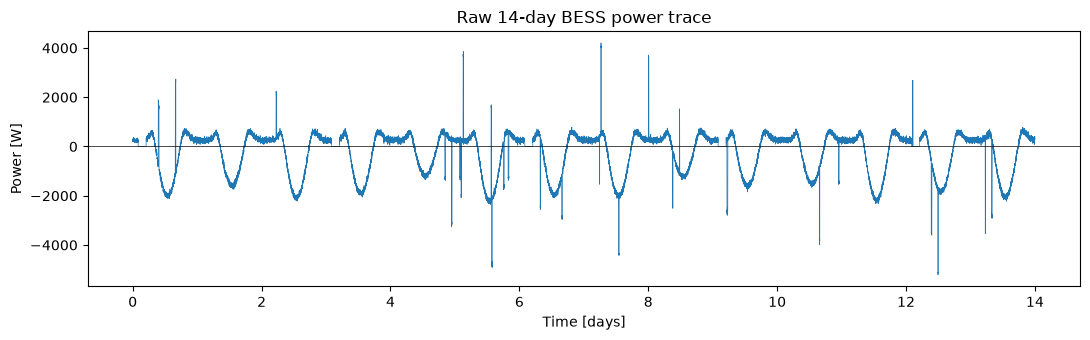

In [2]:
df = pd.read_csv('../sample_data/sample_bess_data.csv')
dt = float(df['time_s'].diff().median())
power = df['power_W'].to_numpy()
t_days = df['time_s'].to_numpy() / 86400.0

print(f"{len(df)} samples, dt = {dt:.0f} s, span = {t_days[-1]:.1f} days")

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_days, power, lw=0.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time [days]'); ax.set_ylabel('Power [W]')
ax.set_title('Raw 14-day BESS power trace')
fig.tight_layout()

## 2. `select_representative_window` — find the most typical window

Split the trace into consecutive non-overlapping 3-day windows and score each one against the *median* behaviour across all windows (positive energy throughput, rest time, sign swaps, energy between swaps). The window with the lowest relative-RMSE score looks most "typical" — no unusually long rest, no outlier spike day.

   WindowIdx         PosWh      RT_h  Nswap    Eswap_Wh     Score
0          1  16189.029887  2.883333  140.0  348.992173  0.031716
1          2  15389.794493  2.850000  142.0  341.426148  0.038933
2          3  15845.089018  2.900000  128.0  369.253263  0.028427
3          4  14757.758630  2.866667  128.0  367.551454  0.037796

Selected window #3 of 4 (score=0.028)


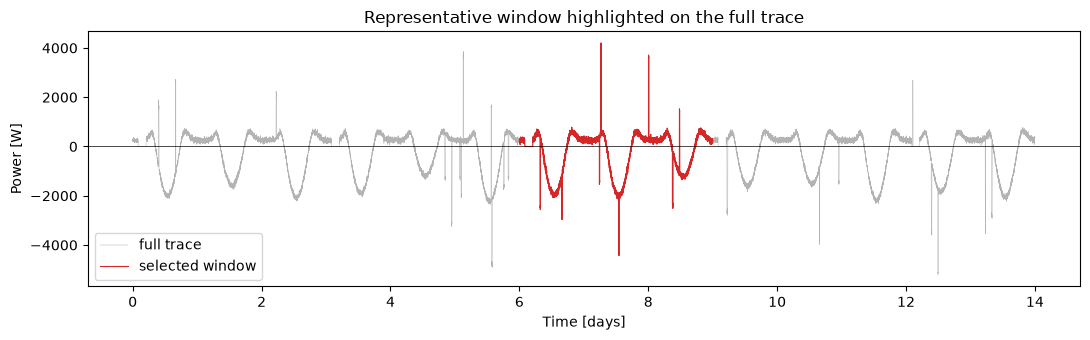

In [3]:
window_sec = 3 * 24 * 3600  # 3-day windows

win_result = select_representative_window(power, dt=dt, window_sec=window_sec)

print(win_result.metrics_table)
print(f"\nSelected window #{win_result.idx_best_matlab} of {win_result.metrics_table.shape[0]} "
      f"(score={win_result.score_per_window[win_result.idx_best]:.3f})")

window_power = win_result.best_window_power
n_win = len(window_power)
start = win_result.idx_best * n_win
end = start + n_win

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(t_days, power, lw=0.35, color='0.7', label='full trace')
ax.plot(t_days[start:end], power[start:end], lw=0.8, color='tab:red', label='selected window')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Time [days]'); ax.set_ylabel('Power [W]')
ax.legend(); ax.set_title('Representative window highlighted on the full trace')
fig.tight_layout()

## 3. `filter_profile` — trim long rests

The selected window still contains a multi-hour overnight rest. For lab testing we don't need to sit through the whole thing — keep the first few minutes of every rest (enough to capture relaxation behaviour) and drop the rest.

kept 4145/4320 samples (4.1% removed)


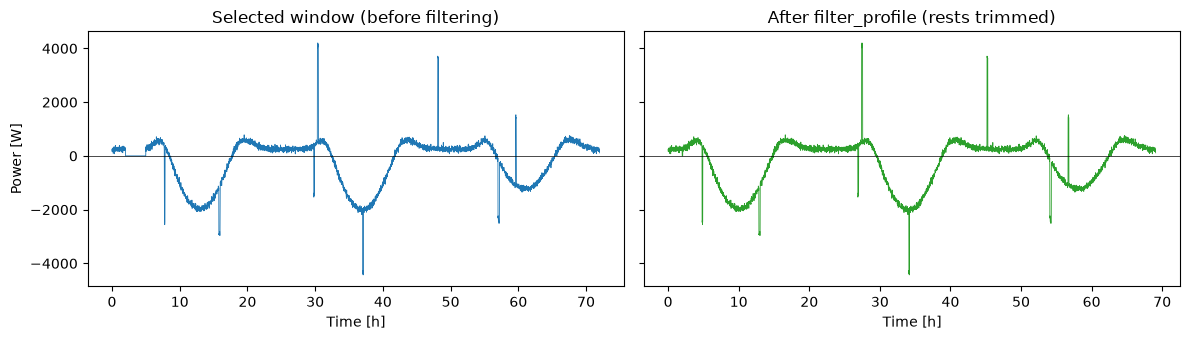

In [4]:
filt = filter_profile(
    window_power,
    filter_rest_threshold=1.0,   # |P| <= 1 W counts as resting
    dt=dt,
    keep_rest_sec=300.0,          # keep the first 5 min of every rest segment
)

print(f"kept {filt.n_kept}/{filt.n_kept + filt.n_removed} samples "
      f"({filt.removed_fraction:.1%} removed)")

t_win_h = np.arange(n_win) * dt / 3600.0
t_filt_h = np.arange(filt.n_kept) * dt / 3600.0

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
axes[0].plot(t_win_h, window_power, lw=0.6)
axes[0].set_title('Selected window (before filtering)')
axes[1].plot(t_filt_h, filt.power_f, lw=0.6, color='tab:green')
axes[1].set_title('After filter_profile (rests trimmed)')
for ax in axes:
    ax.set_xlabel('Time [h]'); ax.axhline(0, color='k', lw=0.5)
axes[0].set_ylabel('Power [W]')
fig.tight_layout()

filtered_power = filt.power_f

## 4. `cell_model_io` — load the target cell

Load a single-cell OCV+R0 model (produced from lab characterization tests) straight from an Excel workbook: SOC/temperature breakpoints, OCV curve, internal resistance map, capacity/efficiency vs. temperature, and (if present) datasheet current limits.

In [5]:
cell = load_cell_model_xlsx('../sample_data/sample_cell_model.xlsx')

print("SOC grid:", cell.cell_model['SOC'].min(), "-", cell.cell_model['SOC'].max())
print("TEMP grid [degC]:", cell.cell_model['TEMP'])
print("Capacity vs temp [Ah]:", cell.cell_model['Q'])
print("Datasheet current limits:", cell.datasheet)
print("Other datasheet fields:", cell.datasheet_meta)

SOC grid: 0.0 - 1.0
TEMP grid [degC]: [-5.  5. 15. 25. 35.]
Capacity vs temp [Ah]: [3.365  3.3669 3.4088 3.4021 3.4105]
Datasheet current limits: {'max_current_charge_A': 21.0, 'max_current_discharge_A': 21.0}
Other datasheet fields: {'voltage_V': 3.6, 'capacity_Ah': 3.35, 'H_mm': 65.0, 'T_mm': 10.0, 'W_mm': 18.5, 'weight_g': 38.5, 'nominal_energy_Wh': 12.06, 'type': 'prismatic'}


## 5. `profile_generation` (power_only mode) — build a reference SOC trace

`profile_generation` supports two relevant modes:

- **`power_only`** — forward-simulate the cell's SOC/current/voltage from a given initial SOC. Used here (and normally used before a profile has ever been run on real hardware).
- **`power_soc`** — given both power *and* a measured SOC trace, grid-search `scale_divisor` / `drift_correction` to find whichever combination best reproduces the measured SOC.

To demonstrate that the tuning in `power_soc` mode actually recovers the right answer, we first forward-simulate our filtered window through the real cell model at a *chosen* `scale_divisor` (standing in for a real bench-measured SOC trace, with the true pack/cell ratio "unknown" to the tuner). Step 6 then tries to recover that same `scale_divisor` from `power` + `soc` alone.

mode: power_only, success: True


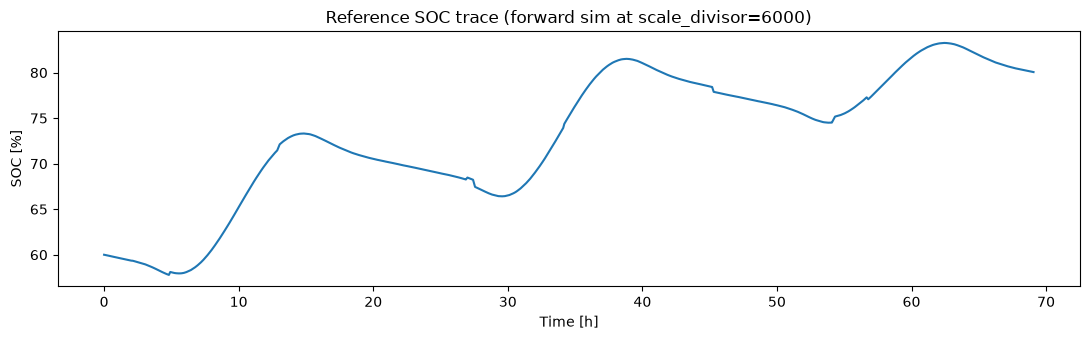

In [6]:
true_scale_divisor = 6000.0  # pretend this is the (unknown-to-the-tuner) real pack/cell ratio

opts_fwd = {
    'dt': dt, 'T_cell_degC': 25,
    'scale_divisor': true_scale_divisor, 'drift_correction': 1.0,
    'tune_scale_divisor': False, 'tune_drift_correction': False,
}
profile_data_fwd = {'power': filtered_power, 'soc_init': 60.0}

out_fwd = profile_generation(cell.cell_model, profile_data_fwd, cell.datasheet, opts_fwd)
print(f"mode: {out_fwd.mode}, success: {out_fwd.success}")

reference_soc = out_fwd.results.soc
t_h = np.arange(len(reference_soc)) * dt / 3600.0

fig, ax = plt.subplots()
ax.plot(t_h, reference_soc, color='tab:blue')
ax.set_xlabel('Time [h]'); ax.set_ylabel('SOC [%]')
ax.set_title(f'Reference SOC trace (forward sim at scale_divisor={true_scale_divisor:.0f})')
fig.tight_layout()

## 6. `profile_generation` (power_soc mode) — recover `scale_divisor` by tuning

Now treat `filtered_power` + `reference_soc` as if they came off the bench, and let `profile_generation` grid-search `scale_divisor` (its default 50-point log-spaced grid from 10 to 10 000) to find the value that reproduces `reference_soc` most closely.

In [7]:
profile_data_tune = {'power': filtered_power, 'soc': reference_soc}
opts_tune = {'dt': dt, 'T_cell_degC': 25}

output = profile_generation(cell.cell_model, profile_data_tune, cell.datasheet, opts_tune)

print(f"mode: {output.mode}, success: {output.success}")
print(f"true scale_divisor:      {true_scale_divisor:.1f}")
print(f"recovered scale_divisor: {output.best_scale_divisor:.1f}")
print(f"recovered drift_correction: {output.best_drift_correction:.3f}")
print(f"SOC RMSE at best fit: {output.tuning.min_rmse:.3f} %")

mode: power_soc, success: True
true scale_divisor:      6000.0
recovered scale_divisor: 5690.0
recovered drift_correction: 1.000
SOC RMSE at best fit: 0.793 %


peak |current|: 0.20 A (datasheet limit: 21 A, using 0.9% of it)


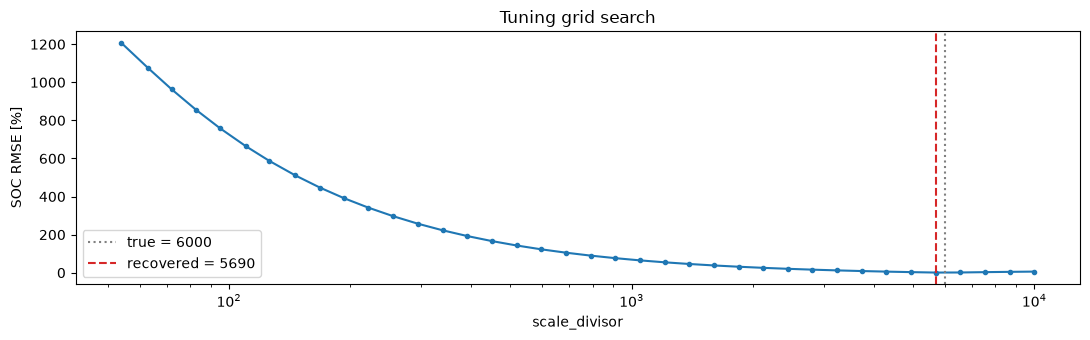

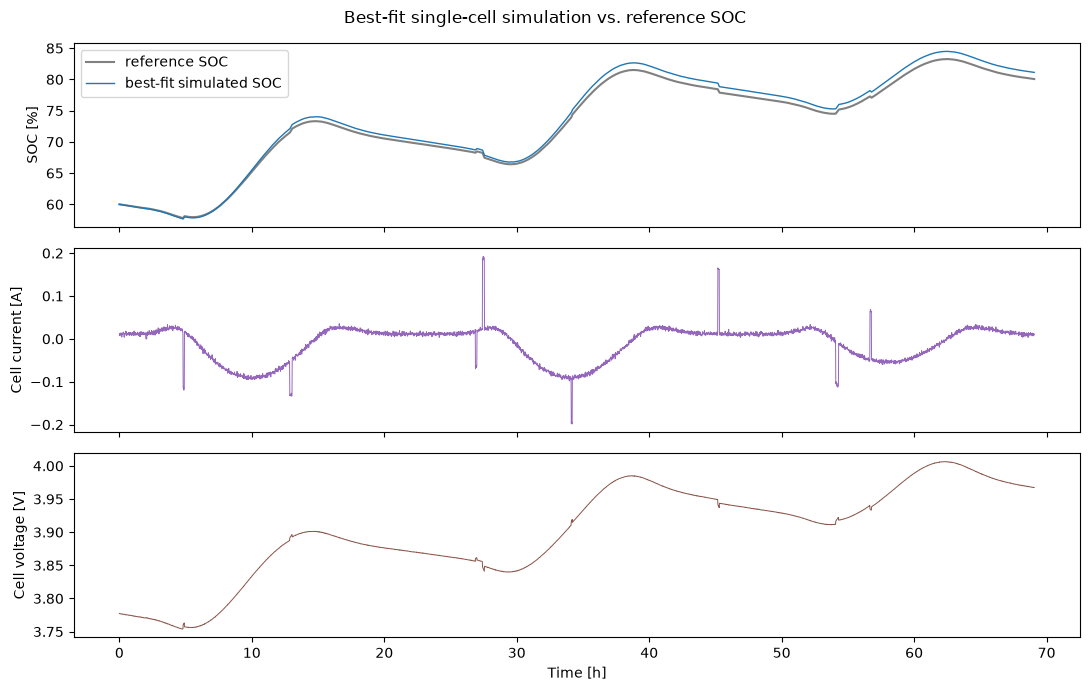

In [8]:
tuning = output.tuning
best = output.best_results

fig, ax = plt.subplots()
ax.semilogx(tuning.scale_values, tuning.rmse_values[:, 0], marker='.')
ax.axvline(true_scale_divisor, color='0.5', ls=':', label=f'true = {true_scale_divisor:.0f}')
ax.axvline(output.best_scale_divisor, color='tab:red', ls='--',
           label=f'recovered = {output.best_scale_divisor:.0f}')
ax.set_xlabel('scale_divisor'); ax.set_ylabel('SOC RMSE [%]')
ax.set_title('Tuning grid search'); ax.legend()
fig.tight_layout()

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(11, 7))
axes[0].plot(t_h, reference_soc, label='reference SOC', color='0.5', lw=1.5)
axes[0].plot(t_h, best.soc, label='best-fit simulated SOC', color='tab:blue', lw=1)
axes[0].set_ylabel('SOC [%]'); axes[0].legend()
axes[1].plot(t_h, best.current, color='tab:purple', lw=0.7)
axes[1].set_ylabel('Cell current [A]')
axes[2].plot(t_h, best.voltage, color='tab:brown', lw=0.7)
axes[2].set_ylabel('Cell voltage [V]'); axes[2].set_xlabel('Time [h]')
fig.suptitle('Best-fit single-cell simulation vs. reference SOC')
fig.tight_layout()

peak_current = np.max(np.abs(best.current))
limit = cell.datasheet['max_current_charge_A']
print(f"peak |current|: {peak_current:.2f} A "
      f"(datasheet limit: {limit:.0f} A, using {peak_current / limit:.1%} of it)")

## Summary

- **`select_representative_window`** cut 14 days down to the 3-day window that best represents the whole trace.
- **`filter_profile`** trimmed the long overnight rest inside that window, shortening it further without losing any dynamic behaviour.
- **`cell_model_io`** loaded the target cell's OCV/R0 model straight from a lab-format Excel workbook.
- **`profile_generation`** was used in both of its modes: `power_only` to forward-simulate a physically consistent SOC trace, and `power_soc` to recover the `scale_divisor` that produced it — landing within the resolution of the default tuning grid, with a low SOC RMSE.

`filtered_power`, together with the recovered `scale_divisor` / `drift_correction`, is the lab-ready single-cell profile: short enough to run on the bench, and validated to reproduce how the pack actually behaves.